<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [5]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-04-11 11:24:03--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.9’

survey-data.csv.9   100%[===================>] 152.13M  38.4MB/s    in 4.0s    

2026-04-11 11:24:09 (38.1 MB/s) - ‘survey-data.csv.9’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [6]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [38]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [8]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [9]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [10]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [11]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [12]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [13]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


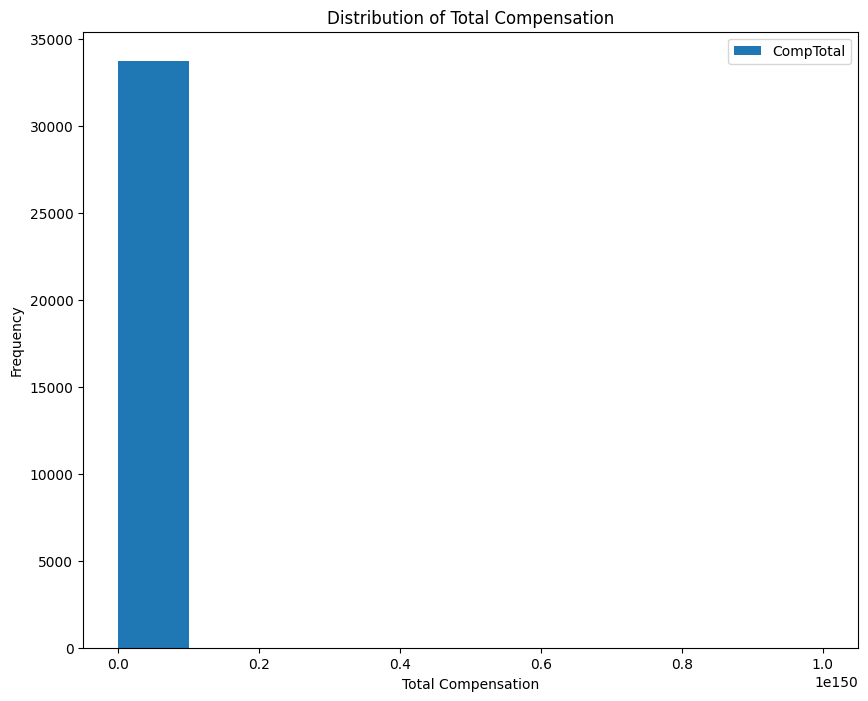

In [14]:
QUERY1 = """
SELECT CompTotal
FROM main
"""
df = pd.read_sql_query(QUERY1,conn)
df.head()
df.plot(kind='hist', figsize=(10, 8) )
plt.title('Distribution of Total Compensation')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')

plt.show()

**Box Plots**

Plot a box plot of Age.


Note: you may need to restart the kernel to use updated packages.


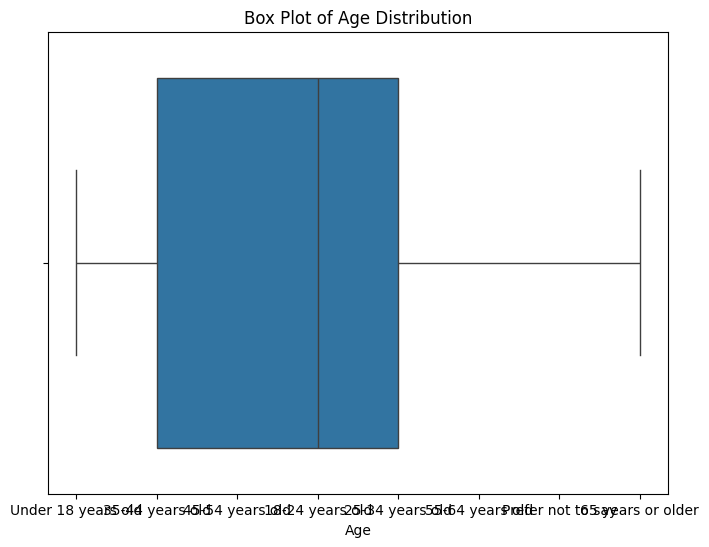

In [20]:

%pip install seaborn
import seaborn as sns

# 1. Query the Age column from the 'main' table
QUERY2 = """
SELECT Age
FROM main
"""

# 2. Load the data into a DataFrame
df_age = pd.read_sql_query(QUERY2, conn)

# 3. Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_age['Age'])

# 4. Add titles and labels
plt.title('Box Plot of Age Distribution')
plt.xlabel('Age')

# Display the plot
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


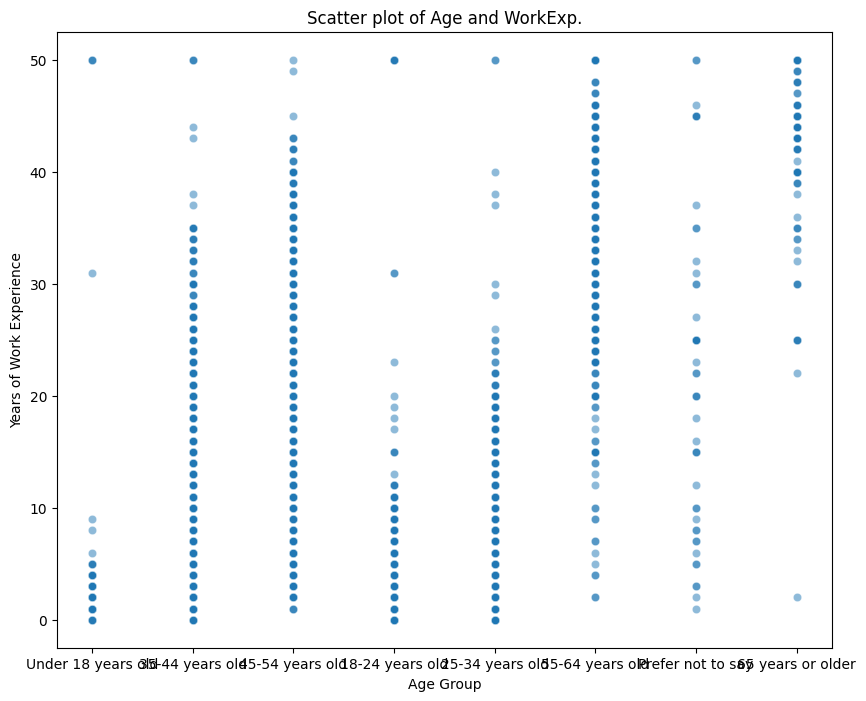

In [31]:
## Write your code here
# 1. Query the Age column from the 'main' table
QUERY3 = """
SELECT Age,WorkExp
FROM main
"""

df_age_workexp = pd.read_sql_query(QUERY3, conn)

plt.figure(figsize=(10,8))
sns.scatterplot(data=df_age_workexp, x='Age', y='WorkExp', alpha=0.5)

# 4. Add titles and labels
plt.title('Scatter plot of Age and WorkExp.')
plt.title('Scatter plot of Age and WorkExp.')
plt.xlabel('Age Group')
plt.ylabel('Years of Work Experience')

# Display the plot
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


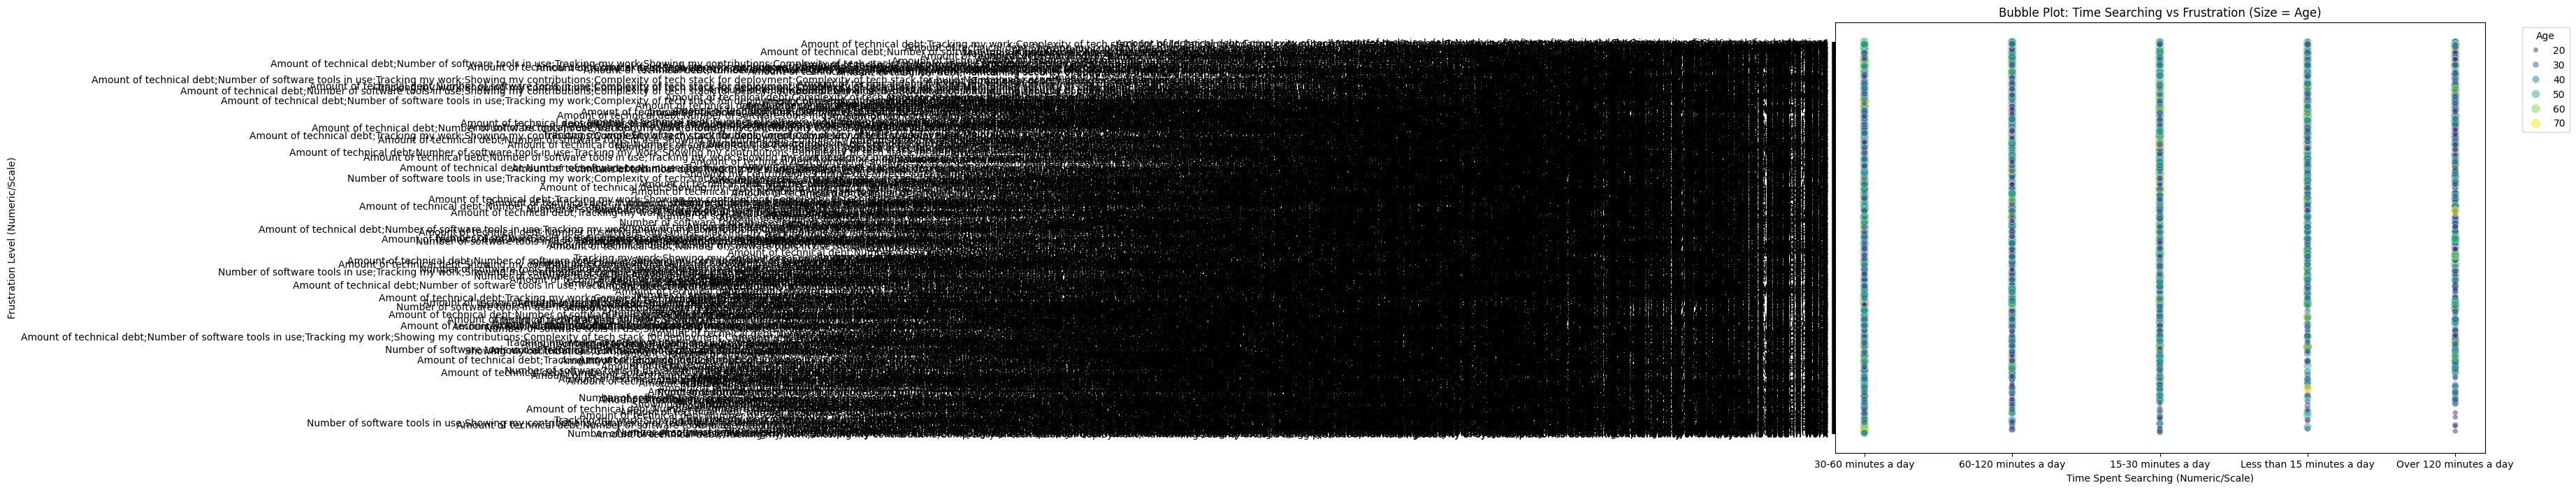

In [33]:
## Write your code here

QUERY4 = """
SELECT TimeSearching, Frustration, Age
FROM main
"""
df_bubble = pd.read_sql_query(QUERY4, conn)

age_map = {
    'Under 18 years old': 15, '18-24 years old': 21, '25-34 years old': 30,
    '35-44 years old': 40, '45-54 years old': 50, '55-64 years old': 60,
    '65 years or older': 70
}

# Apply mappings
df_bubble['Age_Numeric'] = df_bubble['Age'].map(age_map)

#Bubbleplot figure
plt.figure(figsize=(12, 8))

# Using 'size' for the Age and 'hue' for extra clarity
sns.scatterplot(
    data=df_bubble, 
    x='TimeSearching', 
    y='Frustration', 
    size='Age_Numeric',   # This creates the "bubbles"
    hue='Age_Numeric',    # Color by age to make size differences clearer
    sizes=(20, 100),      # Define the min and max size of bubbles
    alpha=0.5,            # Transparency helps see overlapping points
    palette='viridis'
)

# 4. Add labels and legend
plt.title('Bubble Plot: Time Searching vs Frustration (Size = Age)')
plt.xlabel('Time Spent Searching (Numeric/Scale)')
plt.ylabel('Frustration Level (Numeric/Scale)')
plt.legend(title='Age', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


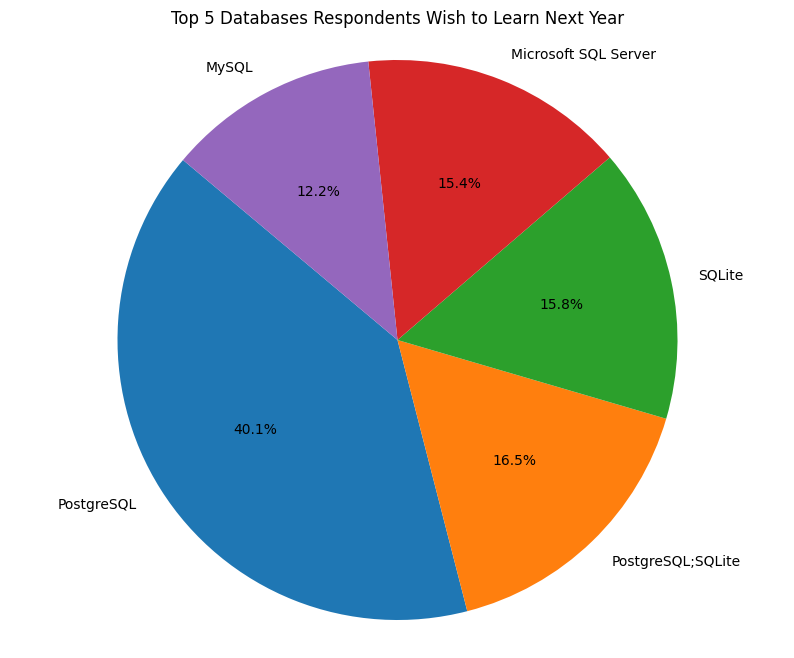

In [49]:
## Write your code here

QUERY5 = """
SELECT DatabaseWantToWorkWith
FROM main
"""

df_db = pd.read_sql_query(QUERY5, conn)

# 2. Process the data
db_counts = df_db['DatabaseWantToWorkWith'].dropna().value_counts()

# 3. Get the Top 5 databases
top_5_db = db_counts.head(5)

# 4. Create the Pie Chart
plt.figure(figsize=(10, 8))
plt.pie(
    top_5_db, 
    labels=top_5_db.index, 
    autopct='%1.1f%%', 
    startangle=140, 
   
)

plt.title('Top 5 Databases Respondents Wish to Learn Next Year')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


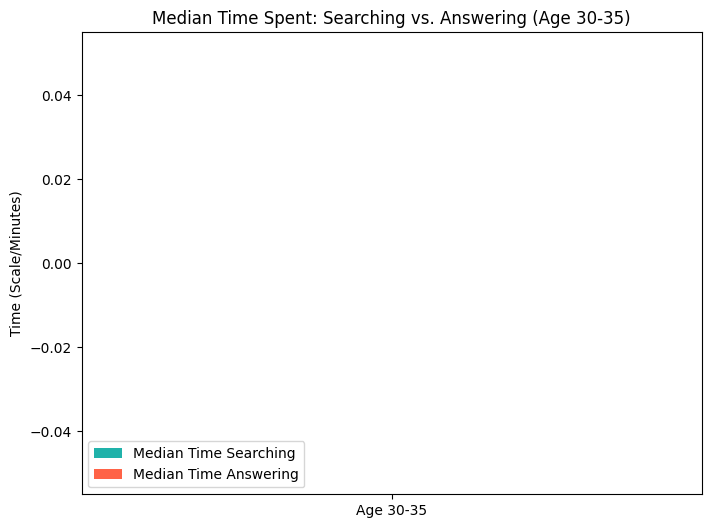

In [61]:
## Write your code here

# 1. Query the necessary columns from the 'main' table
QUERY6 = "SELECT Age, TimeSearching, TimeAnswering FROM main"
df_time = pd.read_sql_query(QUERY6, conn)

# Ensure the time columns are numeric
df_time['TimeSearching'] = pd.to_numeric(df_time['TimeSearching'], errors='coerce')
df_time['TimeAnswering'] = pd.to_numeric(df_time['TimeAnswering'], errors='coerce')

age_map = {
        'Under 18 years old': 15, '18-24 years old': 21, '25-34 years old': 30,
        '35-44 years old': 40, '45-54 years old': 50, '55-64 years old': 60,
        '65 years or older': 70
    }
df_time['Age_Numeric'] = df_time['Age'].map(age_map)

# 3. Filter for the age group 30 to 35
df_filtered = df_time[(df_time['Age_Numeric'] >= 30) & (df_time['Age_Numeric'] <= 35)]

# 4. Calculate Medians
# Median is preferred here to reduce the impact of extreme outliers
median_searching = df_filtered['TimeSearching'].median()
median_answering = df_filtered['TimeAnswering'].median()

# 5. Create the Stacked Bar Chart
plt.figure(figsize=(8, 6))

# Plot the base (TimeSearching)
plt.bar('Age 30-35', median_searching, color='lightseagreen', label='Median Time Searching')

# Plot the second layer (TimeAnswering) on top of the first
plt.bar('Age 30-35', median_answering, bottom=median_searching, color='tomato', label='Median Time Answering')

# Formatting
plt.title('Median Time Spent: Searching vs. Answering (Age 30-35)')
plt.ylabel('Time (Scale/Minutes)')
plt.legend()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


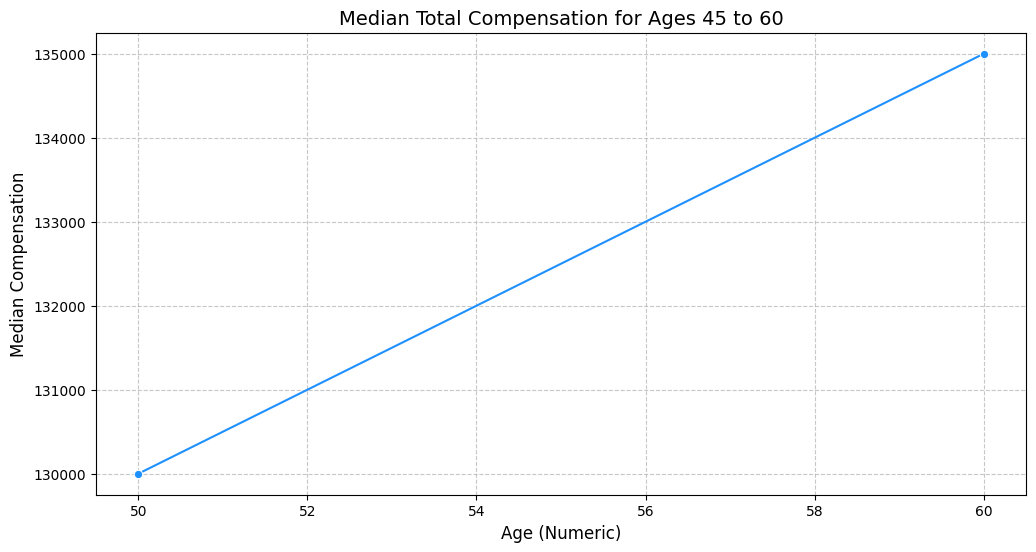

In [64]:

# 1. Query the data
QUERY7 = "SELECT Age, CompTotal FROM main"
df_comp = pd.read_sql_query(QUERY7, conn)

# 2. Map Age to Numeric
age_map = {
    'Under 18 years old': 15, '18-24 years old': 21, '25-34 years old': 30,
    '35-44 years old': 40, '45-54 years old': 50, '55-64 years old': 60,
    '65 years or older': 70
}
df_comp['Age_Numeric'] = df_comp['Age'].map(age_map)

# 3. Clean and Filter
# Convert CompTotal to numeric and filter for the target age range (45-60)
df_comp['CompTotal'] = pd.to_numeric(df_comp['CompTotal'], errors='coerce')
df_filtered = df_comp[(df_comp['Age_Numeric'] >= 45) & (df_comp['Age_Numeric'] <= 60)]

# 4. Calculate Median
# Now group by the new numeric age column
df_median = df_filtered.groupby('Age_Numeric')['CompTotal'].median().reset_index()

# 5. Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_median, x='Age_Numeric', y='CompTotal', marker='o', color='dodgerblue')

plt.title('Median Total Compensation for Ages 45 to 60', fontsize=14)
plt.xlabel('Age (Numeric)', fontsize=12)
plt.ylabel('Median Compensation', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


/tmp/ipykernel_301/55781972.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


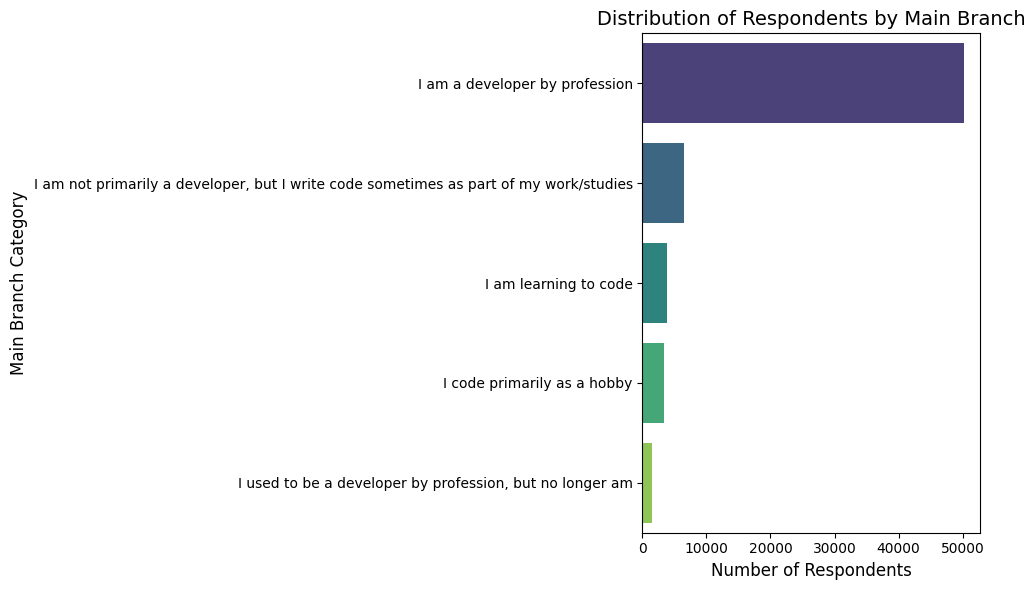

In [66]:
## Write your code here

# 1. Query the frequency of each MainBranch category
# Using SQL to group and count ensures the data is summarized before reaching Python
QUERY = """
SELECT MainBranch, COUNT(*) as Count
FROM main
GROUP BY MainBranch
ORDER BY Count DESC
"""
df_mainbranch = pd.read_sql_query(QUERY, conn)

# 2. Create the horizontal bar chart
plt.figure(figsize=(10, 6))

# We map MainBranch to the y-axis to make it horizontal
sns.barplot(
    data=df_mainbranch, 
    x='Count', 
    y='MainBranch', 
    palette='viridis'
)

# 3. Add titles and labels
plt.title('Distribution of Respondents by Main Branch', fontsize=14)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Main Branch Category', fontsize=12)

plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [68]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
